<a href="https://colab.research.google.com/github/YaS16s/webproject/blob/main/FishDisease1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from PIL import Image
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
df = pd.read_csv("/content/Train.csv")

In [ ]:
df.head()

,Folder Name,Image Filename,Image Path
0,Bacterial diseases - Aeromoniasis,Bacterial diseases - Aeromoniasis (1).jpeg,Freshwater Fish Disease Aquaculture in south a...
1,Bacterial diseases - Aeromoniasis,Bacterial diseases - Aeromoniasis (1).jpg,Freshwater Fish Disease Aquaculture in south a...
2,Bacterial diseases - Aeromoniasis,Bacterial diseases - Aeromoniasis (1).png,Freshwater Fish Disease Aquaculture in south a...
3,Bacterial diseases - Aeromoniasis,Bacterial diseases - Aeromoniasis (10).jpg,Freshwater Fish Disease Aquaculture in south a...
4,Bacterial diseases - Aeromoniasis,Bacterial diseases - Aeromoniasis (100).jpg,Freshwater Fish Disease Aquaculture in south a...


In [ ]:
df.isnull().sum()

,0
Folder Name,0
Image Filename,0
Image Path,0


In [ ]:
df["exists"] = df ["Image Path"].apply(os.path.exists)

In [ ]:
le = LabelEncoder()
df["label"] =le.fit_transform(df["Folder Name"])

In [ ]:
import numpy as np

img_path = df.iloc[0]["Image Path"]

image = Image.open("/content/images (1).jfif")
image.show() # Display the PIL Image object
image = np.array(image) # Then convert to NumPy array

image = image / 255.0

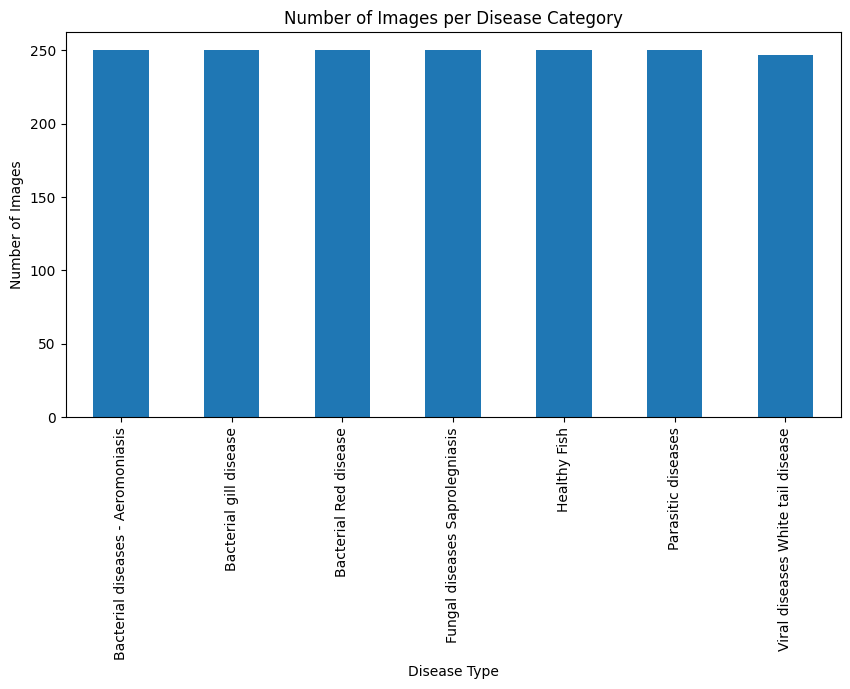

In [ ]:
counts = df["Folder Name"].value_counts()

plt.figure(figsize=(10,5))
counts.plot(kind="bar")

plt.title("Number of Images per Disease Category")
plt.xlabel("Disease Type")
plt.ylabel("Number of Images")

plt.xticks(rotation=90)
plt.show()

In [8]:
import os
import cv2
import zipfile
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from collections import Counter

zip_path = "/content/archive (3).zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(" Dataset extracted")


IMG_SIZE = 224
clean_dir = "/content/clean_dataset"

os.makedirs(clean_dir, exist_ok=True)

# The actual categories are nested within 'Freshwater Fish Disease Aquaculture in south asia/Train' and '/Test'
base_data_path = os.path.join(extract_path, 'Freshwater Fish Disease Aquaculture in south asia')


IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff')

all_categories = []

for main_folder in ['Train', 'Test']:
    main_folder_path = os.path.join(base_data_path, main_folder)
    if os.path.isdir(main_folder_path):

        sub_categories = [d for d in os.listdir(main_folder_path) if os.path.isdir(os.path.join(main_folder_path, d))]
        all_categories.extend(sub_categories)


all_categories = sorted(list(set(all_categories)))
print(" Categories found:", all_categories)


for category in all_categories:
    output_category_path = os.path.join(clean_dir, category)
    os.makedirs(output_category_path, exist_ok=True)


    for main_folder in ['Train', 'Test']:
        input_path = os.path.join(base_data_path, main_folder, category)

        if not os.path.isdir(input_path):
            continue


        image_files = [f for f in os.listdir(input_path) if f.lower().endswith(IMAGE_EXTENSIONS)]

        for img_name in tqdm(image_files, desc=f"Processing {main_folder}/{category}"):
            img_path = os.path.join(input_path, img_name)

            try:
                img = cv2.imread(img_path)


                if img is None:
                    print(f"Warning: Could not read image {img_path}. Skipping.")
                    continue


                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))


                img = cv2.GaussianBlur(img, (5,5), 0)


                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


                img = cv2.equalizeHist(img)


                img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
                lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
                l, a, b = cv2.split(lab)
                clahe = cv2.createCLAHE(clipLimit=2.0)
                l = clahe.apply(l)
                img = cv2.merge((l,a,b))
                img = cv2.cvtColor(img, cv2.COLOR_LAB2BGR)


                img = cv2.bilateralFilter(img, 9, 75, 75)
                img = img / 255.0


                save_path = os.path.join(output_category_path, img_name)
                cv2.imwrite(save_path, (img * 255).astype(np.uint8))

            except Exception as e:
                print(f"Error processing {img_path}: {e}")
                continue

print(" Preprocessing Done!")


counts = {cat: len(os.listdir(os.path.join(clean_dir, cat))) for cat in os.listdir(clean_dir)}
print(" Class Distribution:", counts)

X, y = [], []
label_map = {cat: i for i, cat in enumerate(all_categories)}

for category in all_categories:
    path = os.path.join(clean_dir, category)
    label = label_map[category]

    if not os.path.isdir(path):
        continue # Skip if directory doesn't exist (e.g., if no images were processed for it)

    for img_name in os.listdir(path):
        # Check if the file is an image before trying to read it
        if img_name.lower().endswith(IMAGE_EXTENSIONS):
            img = cv2.imread(os.path.join(path, img_name))
            if img is not None:
                img = img / 255.0
                X.append(img)
                y.append(label)

# Ensure X and y are not empty before converting to numpy arrays
if X and y:
    X = np.array(X)
    y = np.array(y)
    print(" Dataset Loaded:", X.shape)

    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    print(" Train:", X_train.shape)
    print(" Validation:", X_val.shape)
    print(" Test:", X_test.shape)
else:
    print(" No images were loaded into X and y. Cannot perform train_test_split.")


print("  PIPELINE COMPLETE!")

 Dataset extracted
 Categories found: ['Bacterial Red disease', 'Bacterial diseases - Aeromoniasis', 'Bacterial gill disease', 'Fungal diseases Saprolegniasis', 'Healthy Fish', 'Parasitic diseases', 'Viral diseases White tail disease']


Processing Test/Bacterial Red disease: 100%|██████████| 100/100 [00:00<00:00, 141.67it/s]
Processing Train/Bacterial diseases - Aeromoniasis: 100%|██████████| 250/250 [00:01<00:00, 142.90it/s]
Processing Test/Bacterial diseases - Aeromoniasis: 100%|██████████| 100/100 [00:00<00:00, 140.42it/s]
Processing Test/Parasitic diseases: 100%|██████████| 100/100 [00:00<00:00, 138.93it/s]
Processing Train/Viral diseases White tail disease: 100%|██████████| 247/247 [00:01<00:00, 146.93it/s]
Processing Test/Viral diseases White tail disease: 100%|██████████| 97/97 [00:00<00:00, 141.15it/s]


 Preprocessing Done!
 Class Distribution: {'Healthy Fish': 250, 'Viral diseases White tail disease': 247, 'Bacterial gill disease': 250, 'Fungal diseases Saprolegniasis': 250, 'Parasitic diseases': 250, 'Freshwater Fish Disease Aquaculture in south asia': 0, 'Bacterial Red disease': 250, 'Bacterial diseases - Aeromoniasis': 250}
 Dataset Loaded: (1747, 224, 224, 3)
📦 Train: (1222, 224, 224, 3)
📦 Validation: (262, 224, 224, 3)
📦 Test: (263, 224, 224, 3)
  PIPELINE COMPLETE!


In [7]:
import zipfile

zip_path = "/content/archive (3).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    print(zip_ref.namelist())

['Freshwater Fish Disease Aquaculture in south asia/Test/Bacterial Red disease/Bacterial Red disease (1).jpeg', 'Freshwater Fish Disease Aquaculture in south asia/Test/Bacterial Red disease/Bacterial Red disease (1).jpg', 'Freshwater Fish Disease Aquaculture in south asia/Test/Bacterial Red disease/Bacterial Red disease (1).png', 'Freshwater Fish Disease Aquaculture in south asia/Test/Bacterial Red disease/Bacterial Red disease (10).jpg', 'Freshwater Fish Disease Aquaculture in south asia/Test/Bacterial Red disease/Bacterial Red disease (11).jpg', 'Freshwater Fish Disease Aquaculture in south asia/Test/Bacterial Red disease/Bacterial Red disease (116).jpg', 'Freshwater Fish Disease Aquaculture in south asia/Test/Bacterial Red disease/Bacterial Red disease (117).jpg', 'Freshwater Fish Disease Aquaculture in south asia/Test/Bacterial Red disease/Bacterial Red disease (12).jpg', 'Freshwater Fish Disease Aquaculture in south asia/Test/Bacterial Red disease/Bacterial Red disease (129).jpg',